In [1]:
# AzureChatOpenAI 활용하는 방법 서칭해보기

In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="exaone3.5:7.8b",
    temperature=0,
    num_predict=512,
)

small_llm = ChatOllama(
    model="qwen3:4b",
    temperature=0,
    reasoning=False,
    num_predict=512,
)


In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str 
    answer: str  
    context: str

graph_builder = StateGraph(AgentState)

### router

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal


class Route(BaseModel):
    target: Literal['income_tax', 'llm', 'real_estate_tax'] = Field(
        description="The target for the query to answer"
    )   # 3개의 값만 반환하게끔


# system 프롬프트 : 사용자가 할 질문에 대해서 정보를 제공
router_system_prompt = """
You are an expert at routing a user's question to 'income_tax', 'llm', or 'real_estate_tax'.
'income_tax' contains information about income tax up to December 2024.
'real_estate_tax' contains information about real estate tax up to December 2024.
if you think the question is not related to either 'income_tax' or 'real_estate_tax';
you can route it to 'llm'

"""

router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])


structured_router_llm = small_llm.with_structured_output(Route)


def router(state:AgentState) -> Literal['income_tax', 'real_estate_tax', 'llm']:
    """
        질문 분석기 -> LLM을 기반으로 질문을 분석해서 어떤 그래프를 태울지 결정
        Router 의 역할과 동일하다. 
    """
    query = state['query']
    router_chain = router_prompt | structured_router_llm  # [수정; 테스트3 도출 답변 문제] router_llm -> structured_router_llm && Route 타입에러로 StrOutputParser 제거
    route = router_chain.invoke({'query': query})  # query 를 state에서 추출해서 router 체이닝

    print(f'route === {route.target}')  
    return route.target 
    

#### 기본 LLM

In [6]:
from langchain_core.output_parsers import StrOutputParser


def call_llm(state:AgentState):

    query = state['query']
    llm_chain = small_llm | StrOutputParser()

    llm_answer = llm_chain.invoke(query)
    return {'answer' : llm_answer}

In [7]:
from pathlib import Path
import sys

# 루트 경로 추가
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [8]:
from modules.income_tax_graph import graph as income_tax_agent
from modules.real_estate_tax_graph import graph as real_estate_tax_agent


# router 는 conditional_edge로 라우팅만 해주기 때문에, 노드추가 불필요
graph_builder.add_node('income_tax', income_tax_agent)
graph_builder.add_node('real_estate_tax', real_estate_tax_agent)
graph_builder.add_node('llm', call_llm)

전체 레코드 수: 1272
고유 문서 수: 99
중복된 문서 그룹 수: 99
중복으로 추가된 레코드 수: 1173


In [9]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'income_tax':'income_tax',
        'real_estate_tax':'real_estate_tax',
        'llm':'llm'
    }
)

graph_builder.add_edge('income_tax', END)
graph_builder.add_edge('real_estate_tax', END)
graph_builder.add_edge('llm', END)

In [10]:
graph = graph_builder.compile()

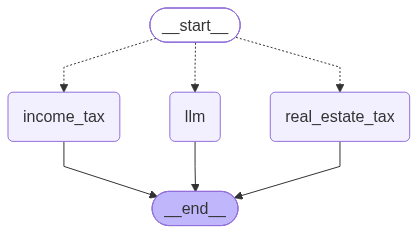

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

#### 테스트 1.

In [12]:
# initial_state = {'query' : '소득세란 무엇인가요?'}
# graph.invoke(initial_state)

In [13]:
"""
* 결과 : 알맞게 라우팅을 해줌
route === income_tax
response== {'Score': 1, 'Explanation': "The provided facts contain significant information directly relevant to defining income tax (소득세). Here's the step-by-step reasoning: \n\n1. **Purpose of Income Tax Law**: The facts include the stated purpose of the Income Tax Law (소득세법), which aims to fairly tax individuals based on their income characteristics and ability to bear tax burdens, contributing to equitable tax burdens and smooth revenue generation (이 법은 개인의 소득의 성격과 납세자의 부담능력 등에 따라 적정하게 과세함으로써 조세부담의 형평을 도모하고 재정수입의 원활한 조달에 이바지함을 목적으로 한다). This directly addresses the essence of what income tax seeks to achieve.\n\n2. **Taxpayer Definitions**: There are detailed definitions provided for different types of taxpayers such as residents (거주자), nonresidents (비거주자), domestic corporations (내국법인), foreign corporations (외국법인), and specific categories of businesses and income sources under the law (사업소득 등 다양한 소득 종류). These definitions underpin how income tax is levied on different entities.\n\n3. **Taxation Scope**: The facts outline various types of income subject to taxation, including business income (사업소득), interest income (이자소득), dividends, rental income, and more (농업, 임업, 어업 소득부터 금융 및 보험업 소득까지 다양한 분야의 소득 종류). This illustrates the broad scope of what qualifies as taxable income under the law.\n\n4. **Calculation and Implementation**: Specific sections detail how income tax is calculated, including taxable income standards (과세표준), tax rates (세율), deductions (공제), and additional taxes like surcharges (가산세). This provides insight into the procedural aspects of determining and paying income tax.\n\nGiven these points, each fact contains elements that are semantically linked to explaining what income tax is—its purpose, who pays it, what it encompasses, and how it is handled legally and procedurally. Therefore, none of the provided facts are completely unrelated to the question about defining income tax (소득세란 무엇인가요?).\n\n**Conclusion**: Based on the criteria provided, the score is 1 because all relevant facts contain keywords and semantic meaning directly connected to defining and understanding income tax."}
answer === 소득세는 개인이나 법인의 소득에 대해 국가가 부과하는 세금으로, 소득의 크기와 성격에 따라 적정하게 과세하여 조세 부담의 공평성을 추구하고 재정 수입을 확보하는 것을 목적으로 합니다. 주로 거주자와 비거주자, 그리고 다양한 사업 소득 등에 대해 과세됩니다. 세율 적용 후 세액공제와 가산세를 고려하여 최종 결정세액을 산출합니다.
hallucination response === not hallucinated
response == {'Score': 1, 'Explanation': 'Step 1: Relevance and Conciseness Evaluation\n- The student answer directly addresses the core definition of income tax (소득세), aligning closely with what the question asks for.\n- While detailed, the answer manages to capture essential elements without unnecessary elaboration, meeting the criteria for being concise yet comprehensive.\n\nStep 2: Accuracy and Completeness Evaluation\n- The definition provided is accurate, correctly identifying income tax as a levy imposed by the state on individual or corporate earnings.\n- It includes key purposes such as ensuring tax fairness (공평성 추구) and generating government revenue (재정 수입 확보), which are fundamental aspects of understanding income tax.\n- The mention of different categories of taxpayers (거주자와 비거주자) and income types (다양한 사업 소득 등) adds valuable context.\n- Additionally, the inclusion of tax calculation elements like 세액공제 (세액공제) and 가산세 (가산세) in relation to 최종 결정세액 (최종 결정세액) further enriches the explanation, providing insight into the practical application of income tax.\n\nStep 3: Conclusion\n- Given that the student answer effectively defines 소득세 (income tax) comprehensively, stays relevant to the question without extraneous information, and enhances understanding through additional practical details, it fully meets the criteria set forth.\n- Therefore, the score is 1, indicating the highest level of compliance with the grading criteria.'}
"""

"""
{'query': '소득세란 무엇인가요?',
 'answer': '소득세는 개인이나 법인의 소득에 대해 국가가 부과하는 세금으로, 소득의 크기와 성격에 따라 적정하게 과세하여 조세 부담의 공평성을 추구하고 재정 수입을 확보하는 것을 목적으로 합니다. 주로 거주자와 비거주자, 그리고 다양한 사업 소득 등에 대해 과세됩니다. 세율 적용 후 세액공제와 가산세를 고려하여 최종 결정세액을 산출합니다.',
 'context': [Document(id='e28c2715-0e23-4e94-b7e0-12b8cb32fbe8', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='법제처 | 13 | 국가법령정보센터\n소득세법\n[전문개정 2009. 12. 31.]\n[시행일: 2025. 7. 1.] 제17조제1항제5호의3, 제17조제1항제5호의4\n제18조 삭제 <2009. 12. 31.>\n제19조(사업소득) ① 사업소득은 해당 과세기간에 발생한 다음 각 호의 소득으로 한다. 다만, 제21조제1항제8호의2에 따른 기타소득으로 원천징수하거나 과세표준확정신고를 한 경우에는 그러하지 아니하다. <개정 2014. 1. 1., 2017. 12. 19., 2018. 12. 31., 2019. 12. 31.>\n  1. 농업(작물재배업 중 곡물 및 기타 식량작물 재배업을 제외한다. 이하 같다)·임업 및 어업에서 발생하는 소득\n  2. 광업에서 발생하는 소득\n  3. 제조업에서 발생하는 소득\n  4. 전기, 가스, 증기 및 공기조절공급업에서 발생하는 소득\n  5. 수도, 하수 및 폐기물 처리, 원료 재생업에서 발생하는 소득\n  6. 건설업에서 발생하는 소득\n  7. 도매 및 소매업에서 발생하는 소득\n  8. 운수 및 창고업에서 발생하는 소득\n  9. 숙박 및 음식점업에서 발생하는 소득\n  10. 정보통신업에서 발생하는 소득\n  11. 금융 및 보험업에서 발생하는 소득\n  12. 부동산업에서 발생하는 소득. 다만, 「공익사업을 위한 토지 등의 취득 및 보상에 관한 법률」 제4조에 따른 공익사업과 관련하여 지역권·지상권(지하 또는 공중에 설정된 권리를 포함한다)을 설정하거나 대여함으로써 발생하는 소득은 제외한다.\n  13. 전문, 과학 및 기술서비스업(대통령령으로 정하는 연구개발업은 제외한다)에서 발생하는 소득\n  14. 사업시설관리, 사업 지원 및 임대 서비스업에서 발생하는 소득\n  15. 교육서비스업(대통령령으로 정하는 교육기관은 제외한다)에서 발생하는 소득\n  16. 보건업 및 사회복지서비스업(대통령령으로 정하는 사회복지사업은 제외한다)에서 발생하는 소득\n  17. 예술, 스포츠 및 여가 관련 서비스업에서 발생하는 소득\n  18. 협회 및 단체(대통령령으로 정하는 협회 및 단체는 제외한다), 수리 및 기타 개인서비스업에서 발생하는 소득\n  19. 가구나 고용활동에서 발생하는 소득\n  20. 제160조제13항에 따른 복식부기의무자가 차량 및 운반구 등 대통령령으로 정하는 사업용 유휴자산을 양도함으로써 발생하는 소득. 다만, 제94조제1항제1호에 따른 양도소득에 해당하는 경우는 제외한다.\n  21. 제1호부터 제20호까지의 규정에 따른 소득과 유사한 소득으로서 영리를 목적으로 자기의 계산과 책임 하에 계속적·반복적으로 행하는 활동을 통하여 얻는 소득\n    ② 사업소득금액은 해당 과세기간의 총수입금액에서 이에 사용된 필요경비를 공제한 금액으로 하며, 필요경비가 총수입금액을 초과하는 경우 그 초과하는 금액을 “결손금”이라 한다.'),
  Document(id='63a082c6-4123-490f-b67a-b09a41f7d739', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='제1장 총칙 <개정 2009. 12. 31.>\n제1조(목적)\n이 법은 개인의 소득에 대하여 소득의 성격과 납세자의 부담능력 등에 따라 적정하게 과세함으로써 조세부담의 형평을 도모하고 재정수입의 원활한 조달에 이바지함을 목적으로 한다.\n[본조신설 2009. 12. 31.]\n[종전 제1조는 제2조로 이동 <2009. 12. 31.>]\n제2조의2(정의)\n① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2010. 12. 27., 2014. 12. 23., 2018. 12. 31.>\n1. "거주자"란 국내에 주소를 두거나 183일 이상의 거소(居所)를 둔 개인을 말한다.\n2. "비거주자"란 거주자가 아닌 개인을 말한다.\n3. "내국법인"이란 「법인세법」 제2조제1호에 따른 내국법인을 말한다.\n4. "외국법인"이란 「법인세법」 제2조제3호에 따른 외국법인을 말한다.\n5. "사업자"란 사업소득이 있는 거주자를 말한다.\n② 제1항에 따른 주소·거소와 거주자·비거주자의 구분은 대통령령으로 정한다.\n[본조신설 2009. 12. 31.]\n제2조(납세의무)\n① 다음 각 호의 어느 하나에 해당하는 개인은 이 법에 따라 각각의 소득에 대한 소득세를 납부할 의무를 진다.\n1. 거주자\n2. 비거주자\n3. 국내원천소득(國內源泉所得)이 있는 개인\n② 다음 각 호의 어느 하나에 해당하는 자는 이 법에 따라 원천징수한 소득세 납부의 의무를 진다.\n1. 거주자\n2. 비거주자\n3. 내국법인\n4. 외국법인의 국내지점 또는 국내영업소(출장소, 그 밖에 이에 준하는 것을 포함한다. 이하 같다)\n5. 그 밖에 이 법에서 정하는 원천징수의무자\n③ 「국세기본법」 제13조제1항에 따른 법인 아닌 단체 중 같은 조 제4항에 따른 법인으로 보는 단체(이하 “법인으로 보는 단체”라 한다) 외의 법인 아닌 단체는 국내에 주소가 없는 경우 또는 사업의 실질적 관리장소를 둘 경우에는 1거주자로, 그 밖의 경우에는 1비거주자로 보아 이 법을 적용한다. 다만, 다음 각 호의 어느 하나에 해당하는 경우에는 소득구성 또는 분배에 따라 해당 단체의 각 구성원별로 이 법 또는 「법인세법」에 따라 소득세 또는 법인세(법인세법에 따른 법인(법인으로 보는 단체를 포함한다)만 여유로 한정한다. 이하 이 조에서 따라납부할 의무를 진다.<개정 2010. 12. 27., 2013. 1. 1., 2018. 12. 31.>\n1. 구성원 간 이익의 분배비율이 정하여져 있고 해당 구성원별로 이익의 분배비율이 확인되는 경우\n2. 구성원 간 이익의 분배비율이 정하여져 있지 아니하거나 사실상 구성원별로 이익이 분배되는 것으로 확인되는 경우\n④ 제3항에도 불구하고 해당 단체의 전체 구성원 중 일부 구성원의 분배비율만 확인되거나 일부 구성원에게 이익이 분배되는 것으로 확인되는 경우에는 다음 각 호의 구분에 따라 소득세 또는 법인세를 납부할 의무를 진다.<신설 2018. 12. 31.>\n소득세법'),
  Document(id='e5ce9eac-155d-4620-9397-1591eda9110a', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='제15조(세액 계산의 순서) 거주자의 종합소득 및 퇴직소득에 대한 소득세는 이 법에 특별한 규정이 있는 경우를 제외하고는 다음 각 호의 따라 계산한다. <개정 2012. 1. 1., 2014. 1. 1., 2019. 12. 31., 2022. 12. 31.>\n1. 제14조에 따라 계산한 각 과세표준에 제55조제1항에 따른 세율(이하 "기본세율"이라 한다)을 적용하여 제55조에 따른 종합소득 산출세액과 퇴직소득 산출세액을 각각 계산한다.\n2. 제1호에 따라 계산한 각 산출세액에서 제60조, 제65조2의, 제75조2, 제75조2의, 제58조, 제59조 및 제59조2의부터 제59조4까지의 규정에 따른 세액공제를 적용하여 종합소득 결정세액과 퇴직소득 결정세액을 각각 계산한다. 이 경우 제56조에 따른 배당세액공제가 있을 때에는 산출세액에서 배당세액공제 금액과 제62조제1항에 따른 금액을 빼고 한 금금액에서 제60조2, 제75조, 제75조2, 제58조, 제59조 및 제59조2의부터 제59조4까지의 규정에 따른 세액공제를 한 금액을 세액으로 한다. 그 밖에 감면되는 세액이 있을 때에는 이를 공제하여 결정세액을 각각 계산한다.\n3. 제2호에 따라 계산한 결정세액에 제13조 및 제13조의2부터 제13조의7까지의 규정과 「국세기본법」 제47조2부터 제47조의4까지의 규정에 따라 가산세를 더하여 종합소득 총결정세액과 퇴직소득 총결정세액을 각각 계산한다.\n[전문개정 2009. 12. 31.]\n제2관 소득의 종류와 금액  <개정 2009. 12. 31.>\n제16조(이자소득) ① 이자소득은 해당 과세기간에 발생한 다음 각 호의 소득으로 한다. <개정 2010. 3. 22., 2012. 1. 1., 2016. 12. 20., 2020. 12. 29., 2024. 12. 31.>\n1. 국가나 지방자치단체가 발행한 채권 또는 증권의 이자와 할인액 \n2. 내국법인이 발행한 채권 또는 증권의 이자와 할인액 \n2의2. 삭제 <2024. 12. 31.>\n3. 국내에서 받은 예금(적금·부금·예탁금 및 우편대체를 포함한다. 이하 같다)의 이자 \n4. 「상호저축은행법」에 따른 신용계(信用契) 또는 신용부금으로 인한 이익 \n5. 외국법인의 국내지점 또는 국내영업소에서 발행한 채권 또는 증권의 이자와 할인액 \n6. 외국법인이 발행한 채권 또는 증권의 이자와 할인액 \n7. 국외에서 받는 예금의 이자 \n8. 대통령령으로 정하는 채권 또는 증권의 환매조건부 매매차익 \n9. 대통령령으로 정하는 저축성보험의 보험차익. 다만, 다음 각 목의 어느 하나에 해당하는 보험의 보험차익은 제외한다.\n가. 최초로 보험료를 납입한 날부터 만기일 또는 중도해지일까지의 기간이 10년 이상으로서 대통령령으로 정하는 요건을 갖춘 보험 \n나. 대통령령으로 정하는 요건을 갖춘 종신형 연금보험 \n10. 대통령령으로 정하는 직장공제회 초과반환금 \n11. 비영업대금(非營業貸金)의 이익 \n12. 제1호부터 제11호까지의 소득과 유사한 소득으로서 금전 사용에 따른 대가로서의 성격이 있는 것')]}
"""

'\n{\'query\': \'소득세란 무엇인가요?\',\n \'answer\': \'소득세는 개인이나 법인의 소득에 대해 국가가 부과하는 세금으로, 소득의 크기와 성격에 따라 적정하게 과세하여 조세 부담의 공평성을 추구하고 재정 수입을 확보하는 것을 목적으로 합니다. 주로 거주자와 비거주자, 그리고 다양한 사업 소득 등에 대해 과세됩니다. 세율 적용 후 세액공제와 가산세를 고려하여 최종 결정세액을 산출합니다.\',\n \'context\': [Document(id=\'e28c2715-0e23-4e94-b7e0-12b8cb32fbe8\', metadata={\'source\': \'../documents/output_docs/income_tax.txt\'}, page_content=\'법제처 | 13 | 국가법령정보센터\n소득세법\n[전문개정 2009. 12. 31.]\n[시행일: 2025. 7. 1.] 제17조제1항제5호의3, 제17조제1항제5호의4\n제18조 삭제 <2009. 12. 31.>\n제19조(사업소득) ① 사업소득은 해당 과세기간에 발생한 다음 각 호의 소득으로 한다. 다만, 제21조제1항제8호의2에 따른 기타소득으로 원천징수하거나 과세표준확정신고를 한 경우에는 그러하지 아니하다. <개정 2014. 1. 1., 2017. 12. 19., 2018. 12. 31., 2019. 12. 31.>\n  1. 농업(작물재배업 중 곡물 및 기타 식량작물 재배업을 제외한다. 이하 같다)·임업 및 어업에서 발생하는 소득\n  2. 광업에서 발생하는 소득\n  3. 제조업에서 발생하는 소득\n  4. 전기, 가스, 증기 및 공기조절공급업에서 발생하는 소득\n  5. 수도, 하수 및 폐기물 처리, 원료 재생업에서 발생하는 소득\n  6. 건설업에서 발생하는 소득\n  7. 도매 및 소매업에서 발생하는 소득\n  8. 운수 및 창고업에서 발생하는 소득\n  9. 숙박 및 음식점업에서 발생하는 소득\n  10. 정보통신업에서 발생하는 소득\n  11. 금융 및 보험업

#### 테스트 2.

In [14]:
# real_estate_initial_state = {'query' : '집 1억은 세금을 얼마나 내나요?'}
# graph.invoke(real_estate_initial_state)

In [15]:
"""
route === real_estate_tax
context === {'query': '오늘날짜:(2026-10-11)에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?', 'follow_up_questions': None, 'answer': 'According to the sources, the 공정시장가액비율 (fair market value rate) for housing as of 2026-10-11 is 60%. This is specified in the 지방세법 시행령 (Local Tax Act Enforcement Regulations), which states that for 2026, the rate for 주택 (housing) is 시가표준액의 100분의 60 (60% of the standard market price). However, there are also mentions of potential future changes, with plans to increase the rate to 70% starting in 2027 and further increases for certain groups.', 'images': ['https://mblogthumb-phinf.pstatic.net/MjAyNjA4MDRfOTgg/MDAxNzg1ODE2NzM4ODI2.fj5xnoSqReUOMJuoL5T0IQTjiVFxu70nBu-C8-wZOQog.APU8G52MVDzGBpEG4A5sxB5v0tyn5qx_RM7jwqllq5Ug.PNG/2026_%EC%84%B8%EC%A0%9C%EA%B0%9C%ED%8E%B8%EC%95%88,_%EC%A2%85%EB%B6%80%EC%84%B8_%EA%B3%B5%EC%A0%95%EC%8B%9C%EC%9E%A5%EA%B0%80%EC%95%A1%EB%B9%84%EC%9C%A8_60%E2%86%9270_%EC%9D%B8%EC%83%81,_3%EC%A3%BC%ED%83%9D%EC%9E%90%EB%8A%94_80_%EC%A0%81%EC%9A%A9.png?type=w800', 'https://dimg.donga.com/wps/NEWS/IMAGE/2026/07/29/134391538.1.jpg', 'https://blogthumb.pstatic.net/MjAyNjA3MThfOTgg/MDAxNzg0MzU4ODgxNTg1.26FfV5gp-Lr_5y9q90F1Z6M6d8VGYqR5APhUpp3X3MEg.aZWTPXxy8K7T4a4yCqvgVrcQKoQ_QCy8QCFTXU7qhksg.PNG/7fbde234-254e-49c1-ae07-c09d68acab66.png?type=w2', 'https://scs-phinf.pstatic.net/MjAyNjAzMjBfMTMw/MDAxNzc0MDA4NDQwNTIz.BOcgrmJeOKlu-kkmEJ2iUPJCy6Jj6dDM4lm3C3hiNfcg.EhCOn8JC85JZu7ZCdq4oXWCGLU6pD1h3zg7bWo-oxTEg.PNG/image.png?type=w800', 'https://www.joseilbo.com/gisa_img_origin/17768184131776818413_rozzhj_origin.png'], 'results': [{'url': 'https://xn--989a00af8jnslv3dba.com/wiki/%EA%B3%B5%EC%A0%95%EC%8B%9C%EC%9E%A5%EA%B0%80%EC%95%A1%EB%B9%84%EC%9C%A8', 'title': '공정시장가액비율 - 부동산위키', 'content': '토지 및 건축물: 70% · 주택 기본: 60% · 주택 + 1세대1주택자(2026년도분) 시가표준액 6억 초과 : 45%; 3억 초과 6억 이하 : 44%; 3억 이하 : 43%.', 'score': 0.8652358, 'raw_content': None, 'images': [], 'id': '62956e-00'}, {'url': 'https://www.newspim.com/news/view/20250818001101', 'title': '"세금으로 부동산 안잡는다더니"...정부, 공정가액비율 80%대 인상 추진', 'content': '국토부는 이번 용역을 통해 새 정부 국정 기조 등을 고려한 내년 공시가격 정책 방향을 설정한다는 목표다. 이에 따라 공시가격이 2026년 과세분부터는 오를 가능성이 대두되고 있다. 만약 공시가격 현실화율을 문재인 정부 시절 로드맵에 따라 운용된다면 2026년 현실화율은 80.9%가 된다. 이렇게 되면 종부세는 1주택자는 20%가량 그리고 다주택자는 50%까지 오를 것이란 게 업계의 분석이다. 현실화율은 매년 10~11월 중앙부동산가격공시위원회 심의에서 확정된다.\n\n또 종부세 세액 산정에 직접적인 영향을 미치는 공정시장가액비율을 문재인 정부시절처럼 90%까지 인상하는 방안이 유력할 것으로 보인다. 공정시장가액비율은 부동산 관련 세금을 부과할 때 과세표준을 산정하는 비율이다. 주택이나 토지의 공시가격에 이 비율을 곱해 실제 세금 부과 기준 금액을 계산한다. 윤석열 정부는 집권 이후 이 비율을 60%로 한정하고 있다. 하지만 문재인 정부 시절 90%까지 높였던 적이 있었던 만큼 이 비율은 당장 내년 종부세 등에 반영될 수 있다. 업계에서는 80%가 적용될 것이란 예측이 나돌고 있는 상태다.', 'score': 0.8190992, 'raw_content': '![KSPOT](/images/common/nav_kspot.png)\n![](/images/sns/ico_youtube.svg)\n\n# [뉴스핌](/)\n\n![뉴스핌](/images/logo.png)\n![](/images/jebo/jebo_kakao.jpg)\n\n[전체메뉴](#)\n\n![KSPOT](/images/common/nav_kspot.png)\n![](/images/sns/ico_youtube.svg)\n![KYD 디데이](/images/kyd/kyd_dday_00.png)\n\n### 속보\n\n# "세금으로 부동산 안잡는다더니"...정부, 공정가액비율 80%대 인상 추진\n\n기사입력 :\n2025년08월19일 07:25\n\n최종수정 :\n2025년08월19일 07:25\n\n![번역](/images/ico_print.svg)\n\n# ※ 본문 글자 크기 조정\n\n# ※ 번역할 언어 선택\n\n[서울=뉴스핌] 이동훈 선임기자 = "세금으로 부동산을 잡지 않겠다"던 이재명 대통령의 대선 전 발언이 또다시 \'빈말\'이 될 전망이다. 정부 안팎에서 부동산 공시가격, 특히 공동주택 공시가격에 대한 인상 계획이 재개될 가능성이 커져서다. 또 현행 60%로 운용되던 공정시장가액비율도 문재인 정부 시절에 다소 못미치는 80%로 상향될 것이란 전망이 나온다.\n\n정부는 최근 발표한 세제 개편안에서 종합부동산세 등에 대한 세율 상향 등은 포함하지 않았지만 공시가격을 높이거나 공정시장가액비율을 높이는 등 \'우회적\'인 세금 인상 방법론이 거론되고 있는 상황이다.\xa0이렇게 되면 서울지역 아파트 소유자들의 종합부동산세와 재산세는 또다시 연간 1000만원 이상이 될 가능성이 지적되고 있다.\n\n19일\xa0관가와 부동산업계에 따르면 세율 등 법을 건드리지 않는 차원에서 각종 우회적 수단 활용에 따른 종합부동산세를 비롯한 부동산 관련 세금 인상 가능성이 거론되고 있다.\n\n우선 윤석열 정부 시절 낮아졌던 부동산 공시가격을 다시 끌어올릴 가능성이다.\xa0국토교통부는 조만간 \'부동산 공시가격 현실화 계획 수정 방향 검토 연구용역\'을 발주하는 것으로 알려졌다.\xa0공시 가격은 재산세, 종합부동산세 등 세금 부과의 기초 자료로 쓰인다. 건강보험료 산정, 기초연금·기초생활보장 수급자 선정 등에도 기준으로 사용된다.\n\n공시가격은 \'현실화 로드맵\'이 없었던 시절에도 정권에 따라 큰 차이를 보였다. 주택 공시가격은 2006년 시작됐다. 노무현 정부 마지막 해인 2007년 서울 공동주택 공시가격은 28.40%로 역대 가장 많이 올랐다. 이어 집값이 떨어졌던 이명박 정부시절과 박근혜 정부시절에는 하락하거나 낮은 상승률을 보였다. 하지만 문재인 정부시절 공시가격 현실화 로드맵이 본격 가동되면서 노무현 정부 시절과 같은 10%대 상승률을 기록했다. 다만 이 때는 실제 집값이 급등하던 시기이기도 했다. 이후 집값이 다시 소강상태로 돌아선 윤석열 정부시절 로드맵이 중단되며 상승세가 잦아들었다.\n\n|  |\n| --- |\n|  |\n\n![](https://img.newspim.com/news/2025/08/18/2508181723068400.jpg)\n![](https://img.newspim.com/news/2025/08/18/2508181723069271.jpg)\n\n특히 노무현 정부 시절 다주택자 규제 방안으로 도입된 종합부동산세가 관건이다. 현행 종부세 과세 기준은 1주택자의 경우 공시가격 12억원을 공제하고 남은 금액에 부과된다. 즉 공시가격이 13억원이면 1억원에 대해서만 세율이 적용돼 종부세가 산정된다. 반면 2주택자의 공제금액은 9억원이다. 2주택자가 두 채를 합쳐 13억원이 공시가격인 주택을 갖고 있다면 4억원에 대해서 종부세를 내야한다. 세율은 2주택자와 1주택자는 동일하다. 3주택 이상 보유자는 중과세 된다.\xa0당초 1주택자 9억원, 다주택자 6억원이었던 공제금액은 윤석열 정부 시절인 2023년 개정됐다. 또 2주택자에 적용되던 중과율도 이때 폐지됐다.\n\n종부세 인상의 관건은 공시가격 인상이다. 민주당 정부는 문재인 정부시절 \'공시가격 현실화 로드맵\'을 가동했다. \'공시가격 현실화\'란 공시가격을 실거래가격에 맞춰 인상하는 것으로 2030년까지 실거래가의 90%까지 끌어올린다는 게 문재인 정부시절 계획이었다. 이는 윤석열 정부의 폐지 방침에 따라 무산될 위기에 놓였지만 \'부동산공시법\'의 개정이 당시 야당이었던 현 여당의 반대로 무산됐다. 대신 윤석열 정부는 2020년 공시가격 \'현실화율\'인 69%를 유지하고 있다. 즉 민주당 정권의 \'공시가격 현실화 로드맵\'은 여전히 살아있는 셈이다.\n\n국토부는 이번 용역을 통해 새 정부 국정 기조 등을 고려한 내년 공시가격 정책 방향을 설정한다는 목표다. 이에 따라 공시가격이 2026년 과세분부터는 오를 가능성이 대두되고 있다.\xa0만약 공시가격 현실화율을 문재인 정부 시절 로드맵에 따라 운용된다면 2026년 현실화율은 80.9%가 된다. 이렇게 되면 종부세는 1주택자는 20%가량 그리고 다주택자는 50%까지 오를 것이란 게 업계의 분석이다.\xa0현실화율은 매년 10~11월 중앙부동산가격공시위원회 심의에서 확정된다.\n\n또 종부세 세액 산정에 직접적인 영향을 미치는\xa0공정시장가액비율을 문재인 정부시절처럼 90%까지 인상하는 방안이 유력할 것으로 보인다.\xa0공정시장가액비율은 부동산 관련 세금을 부과할 때 과세표준을 산정하는 비율이다. 주택이나 토지의 공시가격에 이 비율을 곱해 실제 세금 부과 기준 금액을 계산한다. 윤석열 정부는 집권 이후 이 비율을 60%로 한정하고 있다. 하지만 문재인 정부 시절 90%까지 높였던 적이 있었던 만큼 이 비율은 당장 내년 종부세 등에 반영될 수 있다. 업계에서는 80%가 적용될 것이란 예측이 나돌고 있는 상태다.\n\n부동산 세금 인상 방향에 대해 정부는 아직 검토되지 않았다는 입장이지만 이같은 정부 입장도 서서히 달라지고 있어 결과가 주목된다.\xa0지난달 기획재정부는 종합부동산세 과세 기준인 공정시장가액비율을 현행 60%에서 80%로 상향한다는 보도에 대해 "구체적으로 결정된 바 없다"고 선을 그었다. 이달 초 발표된 \'2025 세제개편안\'에는 부동산 세제가 빠져있었지만 내년 공시가격 실래가 대비 80% 인상 방안이 거론됐다. 하지만 이에 대해 기재부 측의 반론은 없었다.\n\n국토교통부도 지난달까지 공시가격 현실화율 인상 검토설을 두고 "전혀 검토한 적 없다"고 해명했다. 하지만 최근에는 공시가격 현실화율 조정에 대한 검토를 인정하며 "다양한 방안을 고루 검토할 방침"이란 입장으로 선회한 상태다.\n\n업계에서는 이재명 정부의 부동산 세금 인상이 유력할 것으로 내다보고 있다. 한 시장 전문가는 "문재인 정부시절 수준으로 돌아가냐 마냐의 문제지 이미 14조원의 국채 발행이 이뤄진 상황에서 세금 인상은 불가피한 상황"이라며 "대통령이 대선 때 말한 말을 뒤집을 명분을 찾아야 하는데 6.27대책에도 집값이 잡히지 않은 점과 내집마련 수요를 위한 주택 매물 확보 등 문재인 정부시절의 명분이 그대로 재현될 것으로 보인다"고 말했다.\n\ndonglee@newspim.com\n\n![](https://img.newspim.com//mynews/mynews_banner3.jpg)\n\n### [관련기사]\n\n### [관련키워드]\n\n<저작권자(c) 글로벌리더의 지름길 종합뉴스통신사 뉴스핌(Newspim), 무단 전재-재배포 금지>\n\n### GAM\xa0- 해외주식 투자 도우미\n\n![](https://img.newspim.com/news/2026/08/18/2608180159180100_t3.jpg)\n![](https://img.newspim.com/news/2022/10/27/2210272126144390_t3.jpg)\n![](https://img.newspim.com/news/2023/03/24/2303241623401670_565_tc.jpg)\n![](https://img.newspim.com/news/2023/03/24/2303241623401670_565_tc.jpg)\n![](/images/gam_view_bottom3.jpg)\n\n### [뉴스핌 베스트 기사]\n\n![](https://img.newspim.com/news/2026/10/08/2610081601450760_t1.jpg)\n![](https://img.newspim.com/news/2026/10/08/2610081534180140_476_tc.jpg)\n\n### [주요포토]\n\n[![위켄드, 공항에서 친절하게 사인](https://img.newspim.com/slide_image/2026/10/09/26100915510878200_t1.jpg)](http://photo.newspim.com/view?type=national&id=50403)\n\n![위켄드, 공항에서 친절하게 사인](https://img.newspim.com/slide_image/2026/10/09/26100915510878200_t1.jpg)\n\n[\'위켄드, 공항에서 친절하게 사인](http://photo.newspim.com/view?type=national&id=50403)\n\n[![한글날 알리는 세종대왕](https://img.newspim.com/slide_image/2026/10/09/26100909090701300_t1.jpg)](http://photo.newspim.com/view?type=national&id=50400)\n\n![한글날 알리는 세종대왕](https://img.newspim.com/slide_image/2026/10/09/26100909090701300_t1.jpg)\n\n[한글날 알리는 세종대왕](http://photo.newspim.com/view?type=national&id=50400)\n\n[![\'제17회 광화문광장 휘호대회\'](https://img.newspim.com/slide_image/2026/10/09/26100911494410100_t1.jpg)](http://photo.newspim.com/view?type=national&id=50401)\n\n![\'제17회 광화문광장 휘호대회\'](https://img.newspim.com/slide_image/2026/10/09/26100911494410100_t1.jpg)\n\n[\'제17회 광화문광장 휘호대회\'](http://photo.newspim.com/view?type=national&id=50401)\n\n[![한-이집트 정상회담 개최](https://img.newspim.com/slide_image/2026/10/08/26100815070621800_t1.jpg)](http://photo.newspim.com/view?type=national&id=50396)\n\n![한-이집트 정상회담 개최](https://img.newspim.com/slide_image/2026/10/08/26100815070621800_t1.jpg)\n\n[한-이집트 정상회담 개최](http://photo.newspim.com/view?type=national&id=50396)\n\n[![\'가습기살균제 피해자 배상심의 신청\'](https://img.newspim.com/slide_image/2026/10/08/26100813093088700_t1.jpg)](http://photo.newspim.com/view?type=national&id=50389)\n\n![\'가습기살균제 피해자 배상심의 신청\'](https://img.newspim.com/slide_image/2026/10/08/26100813093088700_t1.jpg)\n\n[\'가습기살균제 피해자 배상심의 신청\'](http://photo.newspim.com/view?type=national&id=50389)\n\n[![박홍근 "과감한 개혁으로 구조적 위기 극복"](https://img.newspim.com/slide_image/2026/10/08/26100811442797800_t1.jpg)](http://photo.newspim.com/view?type=national&id=50385)\n\n![박홍근 "과감한 개혁으로 구조적 위기 극복"](https://img.newspim.com/slide_image/2026/10/08/26100811442797800_t1.jpg)\n\n[박홍근 "과감한 개혁으로 구조적 위기 극복"](http://photo.newspim.com/view?type=national&id=50385)\n\n[![ 이억원 "단일종목 레버리지 ETF, 청와대 지시 없었다"](https://img.newspim.com/slide_image/2026/10/08/26100811531749400_t1.jpg)](http://photo.newspim.com/view?type=national&id=50386)\n\n![ 이억원 "단일종목 레버리지 ETF, 청와대 지시 없었다"](https://img.newspim.com/slide_image/2026/10/08/26100811531749400_t1.jpg)\n\n[이억원 "단일종목 레버리지 ETF, 청와대 지시 없었다"](http://photo.newspim.com/view?type=national&id=50386)\n\nS&P 500 기업 중 기사 내용이 영향을 줄 종목 추적\n\n### 긍정 영향 종목\n\n### 부정 영향 종목\n\n![](https://img.newspim.com/web/images/2023/gam_view_right.gif)\n\n### [스팟Live](https://www.youtube.com/playlist?list=PLimlJIbduWCGba26Whri7AsGw26D6zG6r "스팟Live")\n\n[![](https://i.ytimg.com/vi/LvpB5Ozxrw8/maxresdefault.jpg)\n영상](https://www.youtube.com/watch?v=LvpB5Ozxrw8&PLimlJIbduWCGba26Whri7AsGw26D6zG6r)\n\n![](https://i.ytimg.com/vi/LvpB5Ozxrw8/maxresdefault.jpg)\n\n[[스팟Live] \'패륜\' 소리에 폭발한 한민수?..."살다 한민수에게 패륜이라니" | 26.10.08 국회 정무위원회 국정감사 하이라이트](https://www.youtube.com/watch?v=LvpB5Ozxrw8&PLimlJIbduWCGba26Whri7AsGw26D6zG6r)\n\n[![](https://i.ytimg.com/vi/aY5wGwFSpoE/maxresdefault.jpg)\n영상](https://www.youtube.com/watch?v=aY5wGwFSpoE&PLimlJIbduWCGba26Whri7AsGw26D6zG6r)\n\n![](https://i.ytimg.com/vi/aY5wGwFSpoE/maxresdefault.jpg)\n\n[[스팟Live] 카메라 앞에서 국민께 고개 숙인 이억원..."진심으로 송구하고 죄송합니다" | 26.10.08 국회 정무위원회 국정감사 하이라이트](https://www.youtube.com/watch?v=aY5wGwFSpoE&PLimlJIbduWCGba26Whri7AsGw26D6zG6r)\n\n[![](https://i.ytimg.com/vi/zdbTN5Aof_8/maxresdefault.jpg)\n영상](https://www.youtube.com/watch?v=zdbTN5Aof_8&PLimlJIbduWCGba26Whri7AsGw26D6zG6r)\n\n![](https://i.ytimg.com/vi/zdbTN5Aof_8/maxresdefault.jpg)\n\n[[스팟Live] 단일 레버리지 ETF 졸속 과정이 있었다?...김재섭이 확보한 이메일 내용이? | 26.10.08 국회 정무위원회 국정감사 하이라이트](https://www.youtube.com/watch?v=zdbTN5Aof_8&PLimlJIbduWCGba26Whri7AsGw26D6zG6r)\n\n![안다쇼핑](https://img.newspim.com/web/images/2023/pc_andashopping.jpg)\n\n뉴스핌통신등록번호 : 문화,나00032등록일자 : 2018.3.22\n\n뉴스핌등록번호 : 서울아00194등록일자 : 2006.4.26\n\n[한국신문윤리위원회](http://www.ikpec.or.kr/)', 'images': ['https://img.newspim.com/news/2025/08/18/2508181723068400_t1.jpg', 'https://img.newspim.com/news/2025/08/18/2508181723068400.jpg', 'https://www.newspim.com/images/common/nav_kspot.png', 'https://www.newspim.com/images/sns/ico_youtube.svg', 'https://img.newspim.com/news/2025/08/18/2508181723069271.jpg', 'https://img.newspim.com//mynews/mynews_banner3.jpg', 'https://img.newspim.com/news/2026/08/18/2608180159180100_t3.jpg', 'https://img.newspim.com/news/2022/10/27/2210272126144390_t3.jpg', 'https://img.newspim.com/news/2023/03/24/2303241623401670_565_tc.jpg', 'https://www.newspim.com/images/gam_view_bottom3.jpg', 'https://img.newspim.com/news/2026/10/08/2610081601450760_t1.jpg', 'https://img.newspim.com/news/2026/10/08/2610081534180140_476_tc.jpg', 'https://img.newspim.com/slide_image/2026/10/09/26100915510878200_t1.jpg', 'https://img.newspim.com/slide_image/2026/10/09/26100909090701300_t1.jpg', 'https://img.newspim.com/slide_image/2026/10/09/26100911494410100_t1.jpg', 'https://img.newspim.com/slide_image/2026/10/08/26100815070621800_t1.jpg', 'https://img.newspim.com/slide_image/2026/10/08/26100813093088700_t1.jpg', 'https://img.newspim.com/slide_image/2026/10/08/26100811442797800_t1.jpg', 'https://img.newspim.com/slide_image/2026/10/08/26100811531749400_t1.jpg', 'https://i.ytimg.com/vi/LvpB5Ozxrw8/maxresdefault.jpg', 'https://i.ytimg.com/vi/aY5wGwFSpoE/maxresdefault.jpg', 'https://i.ytimg.com/vi/zdbTN5Aof_8/maxresdefault.jpg', 'https://www.newspim.com/images/kyd/kyd_dday_00.png', 'https://img.newspim.com/web/images/2023/gam_view_right.gif', 'https://img.newspim.com/web/images/2023/pc_andashopping.jpg'], 'id': 'c828e2-01'}, {'url': 'https://www.law.go.kr/LSW/lumLsLinkPop.do?lspttninfSeq=120262', 'title': '연계정보', 'content': '법제처 국가법령정보센터\n결과내검색\n저장\n인쇄\n\n1. 지방세법 시행령  \n[시행 2026. 10. 1.] [대통령령 제36736호, 2026. 9. 30., 일부개정]\n\n## 지방세법 시행령\n\n전체조문보기\n\n제109조(공정시장가액비율)  ① 법 제110조제1항 각 호 외의 부분에서 “대통령령으로 정하는 공정시장가액비율”이란 다음 각 호의 구분에 따른 비율을 말한다. <개정 2022. 6. 30., 2023. 3. 14., 2023. 6. 30., 2024. 5. 28., 2025. 5. 27., 2026. 5. 29.>\n\n1. 토지 및 건축물: 시가표준액의 100분의 70\n\n2. 주택: 시가표준액의 100분의 60. 다만, 2026년도에 납세의무가 성립하는 재산세의 과세표준을 산정하는 경우 제110조의2에 따라 1세대 1주택으로 인정되는 주택(시가표준액이 9억원을 초과하는 주택을 포함한다)에 대해서는 다음 각 목의 구분에 따른다.\n\n가. 시가표준액이 3억원 이하인 주택: 시가표준액의 100분의 43\n\n나. 시가표준액이 3억원을 초과하고 6억원 이하인 주택: 시가표준액의 100분의 44\n\n다. 시가표준액이 6억원을 초과하는 주택: 시가표준액의 100분의 45\n\n② 행정안전부장관은 제1항에 따른 공정시장가액비율의 점검ㆍ평가를 위하여 필요한 경우 관계 전문기관에 조사ㆍ연구를 의뢰할 수 있다. <신설 2023. 3. 14.>\n\n닫기\n\n## 법제처\n\n법제처\n\n법제처 국가법령정보센터\n\n법제처 국가법령정보센터', 'score': 0.7507177, 'raw_content': '![법제처 국가법령정보센터](/LSW/images/common/poplogo.gif "법제처 국가법령정보센터가 새창으로 열립니다.")\n![결과내검색](/LSW/images/main/btn_search2.gif)\n![저장](/LSW/images/common/btn_v13fn6.png)\n![인쇄](/LSW/images/common/btn_v13fn7.png)\n\n1. 지방세법 시행령  \n[시행 2026. 10. 1.] [대통령령 제36736호, 2026. 9. 30., 일부개정]\n\n## 지방세법 시행령\n\n![전체조문보기](/LSW/images/button/btn_alljo.gif)\n\n제109조(공정시장가액비율)  ① [법](javascript:; "팝업으로 이동") [제110조](javascript:; "팝업으로 이동")[제1항](javascript:; "팝업으로 이동") 각 호 외의 부분에서 “대통령령으로 정하는 공정시장가액비율”이란 다음 각 호의 구분에 따른 비율을 말한다. <개정 2022. 6. 30., 2023. 3. 14., 2023. 6. 30., 2024. 5. 28., 2025. 5. 27., 2026. 5. 29.>\n\n1. 토지 및 건축물: 시가표준액의 100분의 70\n\n2. 주택: 시가표준액의 100분의 60. 다만, 2026년도에 납세의무가 성립하는 재산세의 과세표준을 산정하는 경우 [제110조의2](javascript:; "팝업으로 이동")에 따라 1세대 1주택으로 인정되는 주택(시가표준액이 9억원을 초과하는 주택을 포함한다)에 대해서는 다음 각 목의 구분에 따른다.\n\n가. 시가표준액이 3억원 이하인 주택: 시가표준액의 100분의 43\n\n나. 시가표준액이 3억원을 초과하고 6억원 이하인 주택: 시가표준액의 100분의 44\n\n다. 시가표준액이 6억원을 초과하는 주택: 시가표준액의 100분의 45\n\n② 행정안전부장관은 제1항에 따른 공정시장가액비율의 점검ㆍ평가를 위하여 필요한 경우 관계 전문기관에 조사ㆍ연구를 의뢰할 수 있다. <신설 2023. 3. 14.>\n\n![닫기](/LSW/images/button/btn_close2.gif)\n\n## 법제처\n\n![법제처](/LSW/images/pop/prlogo1.gif)\n\n![법제처 국가법령정보센터](/LSW/images/pop/prlogo2.gif)\n\n![법제처 국가법령정보센터](/LSW/images/pop/prlogo2.gif)', 'images': ['https://www.law.go.kr/LSW/images/common/poplogo.gif', 'https://www.law.go.kr/LSW/images/main/btn_search2.gif', 'https://www.law.go.kr/LSW/images/common/btn_v13fn6.png', 'https://www.law.go.kr/LSW/images/common/btn_v13fn7.png', 'https://www.law.go.kr/LSW/images/button/btn_alljo.gif', 'https://www.law.go.kr/LSW/images/button/btn_close2.gif', 'https://www.law.go.kr/LSW/images/pop/prlogo1.gif', 'https://www.law.go.kr/LSW/images/pop/prlogo2.gif'], 'id': '5ba17b-02'}, {'url': 'https://blog.naver.com/cnchul/224367713803?viewType=pc', 'title': '조남철의 세금학교 : 네이버 블로그', 'content': '|\n|  |\n\n|  |\n\n| 이 블로그  세법개정안  카테고리 글전체글 보기    화면 최상단으로 이동 |\n\n|\n|  |\n\n[{"title":"2026 세제개편안, 종부세 공정시장가액비율 60%→70% 인상, 3주택자는 80% 적용","source":" ..","domainIdOrBlogId":"cnchul","nicknameOrBlogId":"세무법인 넥스트","logNo":224367713803,"smartEditorVersion":4,"meDisplay":true,"cafeDisplay":true,"blogDisplay":true,"outsideDisplay":true,"lineDisplay":true}]\n\nRSS 2.0 RSS 1.0 ATOM 0.3\n\n---\n\n안녕하세요.  \n이 포스트는 네이버 블로그에서 작성된 게시글입니다.  \n자세한 내용을 보려면 링크를 클릭해주세요.  \n감사합니다.\n\n##### 글 보내기 서비스 안내\n\n2009년 6월 30일 네이버 여행 서비스가 종료되었습니다.  \n 네이버 여행 서비스를 이용해 주신 여러분께 감사드리며,   \n더 좋은 서비스로 보답할 수 있도록 노력하겠습니다.\n\n확인\n\n  \n 닫기\n\n닫기\n\n## 악성코드가 포함되어 있는 파일입니다.\n\n파일{FILENAME}\n\n백신 프로그램으로 치료하신 후 다시 첨부하시거나, 치료가 어려우시면  \n파일을 삭제하시기 바랍니다.\n\n네이버 백신으로 치료하기\n\n고객님의 PC가 악성코드에 감염될 경우 시스템성능 저하,  \n개인정보 유출등의 피해를 입을 수 있으니 주의하시기 바랍니다.\n\n다운로드 취소\n\n닫기 [...] \u200b    2027년: 종부세 대상자에게 70% 적용  2028년 이후: 3주택 이상·조정대상지역 주택 보유자에게 80% 적용  그 외 납세의무자: 70% 유지   \u200b  종부세의 과세기준일은 매년 6월 1일입니다.  현재 발표안대로 개정된다면 2027년 6월 1일 현재의 주택 수와 조정대상지역 주택 보유 여부를 기준으로 첫 번째 인상 비율이 적용될 수 있습니다.  조남철 세무사의 핵심 정리  이번 공정시장가액비율 개편의 핵심은 다음과 같습니다.  \u200b   1. 현재 주택분 종부세 공정시장가액비율은 60%입니다. 2. 2027년부터 원칙적으로 70%로 인상됩니다. 3. 3주택 이상 보유자와 조정대상지역 주택 보유자는 2028년부터 80%가 적용됩니다. 4. 조정대상지역 주택을 보유한 1세대 1주택자는 80% 적용 대상에서 제외됩니다. 5. 공시가격이 그대로여도 공정시장가액비율이 올라가면 종부세 과세표준이 커집니다. 6. 실제 세금은 기본공제, 세율, 세액공제와 세부담 상한을 함께 반영해 계산해야 합니다.   \u200b  특히 1세대 1주택자는 기본공제 확대만 확인해서는 안 됩니다.  다주택자는 주택 수뿐만 아니라 조정대상지역 주택을 한 채라도 보유하고 있는지 확인해야 합니다.  2027년과 2028년에는 적용 비율이 달라질 수 있으므로 연도별 종부세를 각각 계산해 비교할 필요가 있습니다.  이번 내용은 2026년 8월 3일 발표된 세제개편안을 기준으로 작성했습니다. 국회 심의 과정에서 적용 비율과 시행시기가 변경될 수 있습니다.  |  |  | ※ 출처: 재정경제부 「2026년 세제개편안 상세본」 및 「문답자료」  ※ [...] 수 있습니다.  |  |  | ※ 출처: 재정경제부 「2026년 세제개편안 상세본」 및 「문답자료」  ※ 본 내용은 정부 발표안 기준이며, 국회 통과 과정에서 변경될 수 있습니다.  #2026세제개편안 #종합부동산세 #공정시장가액비율 #2027종부세 #1세대1주택 #다주택자종부세 #조정대상지역 #조남철의세금학교 #세무법인넥스트 |  ---  ▼ 관련 글 보러가기 ▼  2026년 세제개편안, 종부세 개편, 1주택자 기본공제 14억 원? 실거주 여부가 중요합니다  2026 세제개편안, 종부세 공정시장가액비율 60%→70% 인상, 3주택자는 80% 적용  2026년 세제개편안, 종부세율, 주택 수가 아니라 주택가액으로 결정됩니다｜2027·2028년 단계적 개편  2026년 세제개편안, 1세대 1주택 종부세 세액공제 개편｜보유보다 실제 거주가 중요해집니다  2026년 세제개편안, 종부세 세부담 상한 150%에서 200%로 인상｜세금이 한 해에 두 배까지 늘어날 수 있습니다  ---  ▼ 관련 영상 보러가기 ▼    ▼ 빠른 전화 상담 ▼  ☎ 1644-7006 / 010-2474-3894  \u200b  ▼ 상담 신청서 작성하기 ▼  세무법인 넥스트 I 세무 상담 신청서 네이버 폼 설문에 바로 참여해 보세요.  form.naver.com  ▼ 공식 웹사이트 ▼  TALA | 세무법인 넥스트 - 기업을 위한 올인원 솔루션 세무, 그 이상의 서비스 | 단순한 세무 관리를 넘어서 기업과 자산의 종합적인 성장을 지원하는 컨설팅 브랜드 TALA  nexttala.com  세무법인 넥스트 본점 서울특별시 강남구 강남대로84길 23', 'score': 0.7011614, 'raw_content': '## 블로그\n\n가벼운 글쓰기툴 퀵에디터가 오픈했어요! [![사용설정하기](https://blogimgs.pstatic.net/nblog/quickeditor/btn_qk_set.gif)](https://admin.blog.naver.com//config/quickposting) [![퀵에디터란?](https://blogimgs.pstatic.net/nblog/quickeditor/btn_what2.gif)](https://section.blog.naver.com/Notice.naver?docId=10000000000020964978) [![설정 닫기](https://blogimgs.pstatic.net/nblog/quickeditor/btn_clse_ly2.gif)](#)\n\n|\n|  |\n\n공지 목록\n\n| 공지글      | 글 제목 | 작성일 | | **공지** [가지급금·차명주식·가업승계·법인컨설팅 | 세무법인 넥스트 법인자문 서비스를 시작합니다](/PostView.naver?blogId=cnchul&logNo=224356263476&categoryNo=21&parentCategoryNo=-1&viewDate=&currentPage=&postListTopCurrentPage=) | 2026. 7. 24. | | **공지** [세무법인 넥스트 세무서비스 1:1 상담 안내](/PostView.naver?blogId=cnchul&logNo=223977171891&categoryNo=21&parentCategoryNo=-1&viewDate=&currentPage=&postListTopCurrentPage=) | 2025. 8. 20. | | **공지** [[법인설립, 법인전환] 세무법인 넥스트 TALA서비스 안내](/PostView.naver?blogId=cnchul&logNo=223842841551&categoryNo=21&parentCategoryNo=-1&viewDate=&currentPage=&postListTopCurrentPage=) | 2025. 4. 22. | | **공지** [[세무법인 넥스트] 조남철 세무사를 소개합니다.](/PostView.naver?blogId=cnchul&logNo=222278520684&categoryNo=71&parentCategoryNo=-1&viewDate=&currentPage=&postListTopCurrentPage=) | 2021. 3. 17. | |\n\n|\n|  |\n\n|\n|  |\n\n|  |\n| --- |\n| [**세법개정안**](# "세법개정안 목록 닫고 열기") 121개의 글[세법개정안목록열기](#) |\n\n|  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 2026 세제개편안, 종부세 공정시장가액비율 60%→70% 인상, 3주택자는 80% 적용  [프로파일](https://blog.naver.com/cnchul) [세무법인 넥스트](https://blog.naver.com/cnchul)   *・*  2026. 8. 4. 13:12  [URL 복사](# "https://blog.naver.com/cnchul/224367713803")  [이웃추가](#) [본문 기타 기능](#) [공유하기](#)  [신고하기](#)    **2027년 종부세 공정시장가액비율 60%→70% 인상, 3주택자는 80% 적용**  안녕하세요. 세무법인 넥스트 대표 세무사 조남철입니다.  2026년 8월 3일 발표된 세제개편안에는 주택분 종합부동산세의 공정시장가액비율을 인상하는 내용이 포함됐습니다.  현재 60%인 공정시장가액비율을 2027년부터 70%로 올리고, 3주택 이상 보유자와 조정대상지역 주택 보유자는 2028년부터 80%까지 인상하는 내용입니다.  \u200b  공정시장가액비율이 올라가면 집값이나 공시가격이 그대로여도 종부세 과세표준이 커집니다.  따라서 종부세 과세대상에 해당하는 주택 보유자는 기본공제 조정과 함께 이번 개편 내용을 반드시 확인해야 합니다.  공정시장가액비율은 종부세를 계산할 때 공시가격에서 기본공제금액을 뺀 나머지 금액 중 실제 과세표준에 반영하는 비율입니다.  \u200b  주택분 종부세 과세표준은 다음과 같이 계산합니다.  종부세 과세표준  =(주택 공시가격 합계-기본공제금액)×공정시장가액비율  예를 들어 공시가격에서 기본공제금액을 뺀 금액이 10억 원이라고 가정하겠습니다.  현재 공정시장가액비율 60%를 적용하면 종부세 과세표준은 6억 원입니다.  공정시장가액비율이 70%로 올라가면 과세표준은 7억 원이 되고, 80%가 적용되면 8억 원이 됩니다.  |  |  | | --- | --- | | **공정시장가액비율** | **종부세 과세표준** | | 60% | 6억 원 | | 70% | 7억 원 | | 80% | 8억 원 |  같은 주택이고 공시가격도 변하지 않았지만, 세율을 적용하는 과세표준은 최대 2억 원 증가합니다.  공정시장가액비율을 종부세의 ‘볼륨 조절 장치’라고 생각하면 이해하기 쉽습니다. 비율이 낮아지면 과세표준이 줄어 종부세 부담도 줄어들고, 비율이 높아지면 과세표준이 커져 종부세 부담도 늘어납니다.  **현재 공정시장가액비율은 60%**  주택분 종부세의 공정시장가액비율은 현재 60%입니다. 공시가격 현실화율 완화와 공정시장가액비율 인하가 함께 적용되면서 주택 시가에 비해 종부세 과세표준이 낮게 반영되고 있다는 것이 정부의 개정 이유입니다.  \u200b  이에 따라 이번 세제개편안에서는 주택 수와 주택 소재지에 따라 공정시장가액비율을 70% 또는 80%까지 올리기로 했습니다.  **1주택자와 지방 2주택자는 70%**  개정안에 따르면 다음 대상자는 2027년부터 공정시장가액비율 70%를 적용받습니다.  \u200b   * **1세대 1주택자** * **지방에 주택을 보유한 1주택자** * **지방주택만 보유한 2주택자** * **조정대상지역 주택을 보유한 1세대 1주택자** * **그 밖에 80% 적용 대상이 아닌 납세의무자**   **\u200b**  현재 60%에서 2027년부터 70%로 10%포인트 인상되는 것입니다.  1세대 1주택자는 종부세 과세 기준과 기본공제금액이 확대될 수 있지만, 공정시장가액비율은 반대로 올라갑니다.  따라서 기본공제가 12억 원에서 14억 원으로 늘어난다는 사실만으로 종부세가 무조건 줄어든다고 판단해서는 안 됩니다.  \u200b  공시가격이 비교적 낮은 1주택자는 기본공제 확대 효과가 더 클 수 있지만, 공시가격이 높은 주택은 과세표준 증가와 세율 조정의 영향이 더 크게 나타날 수 있습니다.  **3주택자와 조정대상지역 주택 보유자는 80%**  다음 대상자는 공정시장가액비율이 단계적으로 80%까지 올라갑니다.  \u200b   * **3주택 이상 보유자** * **조정대상지역 주택 보유자** * **조정대상지역 주택 1채와 비조정대상지역 주택 1채를 보유한 2주택자**   \u200b  다만 조정대상지역에 주택을 보유하고 있더라도 1세대 1주택자는 80% 적용 대상에서 제외됩니다.  적용 일정은 다음과 같습니다.  |  |  |  |  | | --- | --- | --- | --- | | **구분** | **2026년** | **2027년** | **2028년 이후** | | 1세대 1주택자 등 | 60% | 70% | 70% | | 3주택 이상·조정대상지역 주택 보유자 | 60% | 70% | 80% |  3주택 이상 보유자와 조정대상지역 주택 보유자는 2027년에 70%, 2028년부터 80%가 적용됩니다.  2년 동안 과세표준이 단계적으로 증가하는 구조입니다.  **공정시장가액비율이 오르면 세금도 같은 비율로 오를까?**  공정시장가액비율이 60%에서 70%로 올라간다고 해서 종부세가 정확히 10% 증가하는 것은 아닙니다.  종부세는 다음 요소를 모두 반영해 계산하기 때문입니다.  \u200b   * **주택 공시가격** * **기본공제금액** * **공정시장가액비율** * **과세표준 구간별 세율** * **공제할 재산세액** * **1세대 1주택자의 연령·거주기간 세액공제** * **세부담 상한**   **\u200b**  공정시장가액비율이 올라가면 세율을 곱하는 과세표준이 커집니다. 과세표준이 커지면서 더 높은 세율 구간으로 이동하면 실제 종부세 증가 폭은 공정시장가액비율의 인상 폭보다 커질 수도 있습니다.  \u200b  반대로 1세대 1주택자의 기본공제가 확대되거나 세액공제가 적용되면 증가 폭이 줄어들 수 있습니다.  **사례로 보는 과세표준 변화**  공시가격 합계가 30억 원이고 기본공제 후 금액이 20억 원인 주택 보유자를 가정해 보겠습니다. 다른 공제와 세율은 고려하지 않고 공정시장가액비율에 따른 과세표준만 비교하겠습니다.  |  |  |  | | --- | --- | --- | | **연도·적용비율** | **계산** | **과세표준** | | 현행 60% | 20억 원×60% | 12억 원 | | 2027년 70% | 20억 원×70% | 14억 원 | | 2028년 80% | 20억 원×80% | 16억 원 |  60%를 적용할 때 과세표준은 12억 원이지만, 70%가 적용되면 14억 원, 80%가 적용되면 16억 원으로 증가합니다.  \u200b  공시가격이 변하지 않아도 과세표준이 4억 원 커질 수 있습니다.  다만 실제 종부세는 주택 수와 거주 여부에 따른 기본공제, 구간별 세율과 세액공제 등을 추가로 반영해야 합니다.  **언제부터 적용될까?**  개정안 기준으로 공정시장가액비율 인상은 다음과 같이 적용될 예정입니다.  \u200b   * **2027년: 종부세 대상자에게 70% 적용** * **2028년 이후: 3주택 이상·조정대상지역 주택 보유자에게 80% 적용** * **그 외 납세의무자: 70% 유지**   \u200b  종부세의 과세기준일은 매년 6월 1일입니다.  현재 발표안대로 개정된다면 2027년 6월 1일 현재의 주택 수와 조정대상지역 주택 보유 여부를 기준으로 첫 번째 인상 비율이 적용될 수 있습니다.  **조남철 세무사의 핵심 정리**  이번 공정시장가액비율 개편의 핵심은 다음과 같습니다.  \u200b   1. **현재 주택분 종부세 공정시장가액비율은 60%입니다.** 2. **2027년부터 원칙적으로 70%로 인상됩니다.** 3. **3주택 이상 보유자와 조정대상지역 주택 보유자는 2028년부터 80%가 적용됩니다.** 4. **조정대상지역 주택을 보유한 1세대 1주택자는 80% 적용 대상에서 제외됩니다.** 5. **공시가격이 그대로여도 공정시장가액비율이 올라가면 종부세 과세표준이 커집니다.** 6. **실제 세금은 기본공제, 세율, 세액공제와 세부담 상한을 함께 반영해 계산해야 합니다.**   \u200b  특히 1세대 1주택자는 기본공제 확대만 확인해서는 안 됩니다.  다주택자는 주택 수뿐만 아니라 조정대상지역 주택을 한 채라도 보유하고 있는지 확인해야 합니다.  2027년과 2028년에는 적용 비율이 달라질 수 있으므로 연도별 종부세를 각각 계산해 비교할 필요가 있습니다.  이번 내용은 2026년 8월 3일 발표된 세제개편안을 기준으로 작성했습니다. 국회 심의 과정에서 적용 비율과 시행시기가 변경될 수 있습니다.  |  | | --- | | **※ 출처: 재정경제부 「2026년 세제개편안 상세본」 및 「문답자료」**  **※ 본 내용은 정부 발표안 기준이며, 국회 통과 과정에서 변경될 수 있습니다.**  **#2026세제개편안 #종합부동산세 #공정시장가액비율 #2027종부세 #1세대1주택 #다주택자종부세 #조정대상지역 #조남철의세금학교 #세무법인넥스트** |  ---  **▼ 관련 글 보러가기 ▼**  [**2026년 세제개편안, 종부세 개편, 1주택자 기본공제 14억 원? 실거주 여부가 중요합니다**](https://blog.naver.com/cnchul/224367704772)  [**2026 세제개편안, 종부세 공정시장가액비율 60%→70% 인상, 3주택자는 80% 적용**](https://blog.naver.com/cnchul/224367713803)  [**2026년 세제개편안, 종부세율, 주택 수가 아니라 주택가액으로 결정됩니다｜2027·2028년 단계적 개편**](https://blog.naver.com/cnchul/224367814883)  [**2026년 세제개편안, 1세대 1주택 종부세 세액공제 개편｜보유보다 실제 거주가 중요해집니다**](https://blog.naver.com/cnchul/224367823076)  [**2026년 세제개편안, 종부세 세부담 상한 150%에서 200%로 인상｜세금이 한 해에 두 배까지 늘어날 수 있습니다**](https://blog.naver.com/cnchul/224367835256)  ---  **▼ 관련 영상 보러가기 ▼**    **▼ 빠른 전화 상담 ▼**  **☎ 1644-7006 / 010-2474-3894**  **\u200b**  **▼ 상담 신청서 작성하기 ▼**  [**세무법인 넥스트 I 세무 상담 신청서** 네이버 폼 설문에 바로 참여해 보세요.  form.naver.com](https://form.naver.com/response/6kcxJEakiGE6gHSdgwu02g)  **▼ 공식 웹사이트 ▼**  [**TALA | 세무법인 넥스트 - 기업을 위한 올인원 솔루션** 세무, 그 이상의 서비스 | 단순한 세무 관리를 넘어서 기업과 자산의 종합적인 성장을 지원하는 컨설팅 브랜드 TALA  nexttala.com](https://nexttala.com/)  [**세무법인 넥스트 본점** 서울특별시 강남구 강남대로84길 23 한라클래식 405호](#)  [**세무법인 넥스트 용인지점** 경기도 용인시 처인구 포곡읍 포곡로 113 3층 302호](#)  **\u200b**  [저작자 명시 필수 영리적 사용 불가 내용 변경 불가](http://creativecommons.org/licenses/by-nc-nd/2.0/kr/)  저작자 명시 필수 - 영리적 사용 불가 - 내용 변경 불가  **태그**  [취소](#) [확인](#)  [공감 0](#)   * [공감 0](#ratingbutton-like) * [칭찬 0](#ratingbutton-impressive) * [감사 0](#ratingbutton-thanks) * [웃김 0](#ratingbutton-haha) * [놀람 0](#ratingbutton-wow) * [슬픔 0](#ratingbutton-sad)  [이 글에 공감한 블로거 열고 닫기](#)  [댓글   *쓰기*  이 글에 댓글 단 블로거 열고 닫기](#)  [인쇄](#)  [댓글쓰기](# "새 창") **1**/1  [이전](#)   [다음](#) |\n\n|\n|  |\n\n|  |\n| --- |\n| 이 블로그  [**세법개정안**](/PostList.naver?blogId=cnchul&categoryNo=15&from=thumbnailList&parentCategoryNo=0)  카테고리 글[전체글 보기](/PostList.naver?blogId=cnchul&categoryNo=15&from=thumbnailList&parentCategoryNo=0)    [화면 최상단으로 이동](#) |\n\n|\n|  |\n\n[{"title":"2026 세제개편안, 종부세 공정시장가액비율 60%→70% 인상, 3주택자는 80% 적용","source":"https://blog.naver.com/cnchul/224367713803","blogName":"조남철의 ..","domainIdOrBlogId":"cnchul","nicknameOrBlogId":"세무법인 넥스트","logNo":224367713803,"smartEditorVersion":4,"meDisplay":true,"cafeDisplay":true,"blogDisplay":true,"outsideDisplay":true,"lineDisplay":true}]\n\n---\n\n[RSS 2.0](https://rss.blog.naver.com/cnchul.xml) [RSS 1.0](https://rss.blog.naver.com/cnchul.xml?rss=1.0) [ATOM 0.3](https://rss.blog.naver.com/cnchul.xml?atom=0.3)\n\n---\n\n\n\n---\n\n안녕하세요.  \n이 포스트는 네이버 블로그에서 작성된 게시글입니다.  \n자세한 내용을 보려면 링크를 클릭해주세요.  \n감사합니다.\n\n##### 글 보내기 서비스 안내\n\n2009년 6월 30일 네이버 여행 서비스가 종료되었습니다.  \n 네이버 여행 서비스를 이용해 주신 여러분께 감사드리며,   \n더 좋은 서비스로 보답할 수 있도록 노력하겠습니다.\n\n[![확인](https://ssl.pstatic.net/static/common/btn/btn_confirm2.gif)](#)\n\n  \n [![닫기](https://blogimgs.pstatic.net/nblog/mylog/post/btn_thin_close.gif)](#)\n\n[![닫기](https://blogimgs.pstatic.net/imgs/btn_close8.gif)](#)\n\n## 악성코드가 포함되어 있는 파일입니다.\n\n![파일](https://blogimgs.pstatic.net/nblog/mylog/post/ico_file.gif){FILENAME}\n\n백신 프로그램으로 치료하신 후 다시 첨부하시거나, 치료가 어려우시면  \n파일을 삭제하시기 바랍니다.\n\n[네이버 백신으로 치료하기](http://security.naver.com/index.nhn)\n\n고객님의 PC가 악성코드에 감염될 경우 시스템성능 저하,  \n개인정보 유출등의 피해를 입을 수 있으니 주의하시기 바랍니다.\n\n[![다운로드](https://blogimgs.pstatic.net/nblog/mylog/post/btn_download2.gif)](FILEPATH) [![취소](https://blogimgs.pstatic.net/nblog/mylog/post/btn_cancel3.gif)](#)\n\n[![닫기](https://blogimgs.pstatic.net/imgs/btn_close3.gif)](#)\n\n## 작성자 이외의 방문자에게는 이용이 제한되었습니다.\n\n{ALERTMESSAGE}\n\n이용제한 파일 : {FILENAME}\n\n[![다운로드](https://blogimgs.pstatic.net/nblog/mylog/post/btn_download2.gif)](FILEPATH) [![취소](https://blogimgs.pstatic.net/nblog/mylog/post/btn_cancel3.gif)](#)\n\n[![닫기](https://blogimgs.pstatic.net/imgs/btn_close3.gif)](#)\n\n[![닫기](https://blogimgs.pstatic.net/nblog/mylog/post/btn_close5.gif)](#)\n\n[![확인](https://blogimgs.pstatic.net/nblog/mylog/post/btn_confirm.gif)](#) [![취소](https://blogimgs.pstatic.net/nblog/mylog/post/btn_cancel.gif)](#)\n\n[![닫기](https://blogimgs.pstatic.net/nblog/btn_close_1.gif)](#)\n\n[![사진정보 보기](https://blogimgs.pstatic.net/nblog/mylog/post/btn_viewexif.gif)](#)\n\n[![원본 저장하기](https://blogimgs.pstatic.net/nblog/mylog/post/btn_originaldn.gif)](#)   [![사진정보 보기](https://blogimgs.pstatic.net/nblog/mylog/post/btn_viewexif.gif)](#) \n\n* [내PC 저장](#)\n* [N드라이브 저장](#)\n\n[![닫기](https://blogimgs.pstatic.net/imgs/nblog/spc.gif)](#)  ![사진정보보기](https://blogimgs.pstatic.net/nblog/mylog/post/tit_viewexif.gif)  \n\n카메라 모델\n\n해상도\n\n노출시간\n\n노출보정\n\n프로그램모드\n\nISO감도\n\n조리개값\n\n초점길이\n\n측광모드\n\n촬영일시\n\n#### 글보내기 제한 공지\n\n:   저작권 침해가 우려되는 컨텐츠가 포함되어 있어  \n     글보내기 기능을 제한합니다.\n\n네이버는 블로그를 통해 저작물이 무단으로 공유되는 것을 막기 위해, 저작권을 침해하는 컨텐츠가 포함되어 있는 게시물의 경우 글보내기 기능을 제한하고 있습니다.\n\n상세한 안내를 받고 싶으신 경우 네이버 고객센터로 문의주시면 도움드리도록 하겠습니다. 건강한 인터넷 환경을 만들어 나갈 수 있도록 고객님의 많은 관심과 협조를 부탁드립니다.\n\n[![닫기](https://blogimgs.pstatic.net/nblog/book/publishingcompany/btn_close.gif)](#BtnCLose)\n\n#### 주제 분류 제한 공지\n\n:   저작권 침해가 우려되는 컨텐츠가 포함되어 있어  \n     주제 분류 기능을 제한합니다.\n\n네이버는 블로그를 통해 저작물이 무단으로 공유되는 것을 막기 위해, 저작권을 침해하는 컨텐츠가 포함되어 있는 게시물의 경우 주제 분류 기능을 제한하고 있습니다.\n\n상세한 안내를 받고 싶으신 경우 네이버 고객센터로 문의주시면 도움드리도록 하겠습니다. 건강한 인터넷 환경을 만들어 나갈 수 있도록 고객님의 많은 관심과 협조를 부탁드립니다.\n\n[![닫기](https://blogimgs.pstatic.net/nblog/book/publishingcompany/btn_close.gif)](#BtnCLose)\n\n작성하신 **게시글에 사용이 제한된 문구가 포함**되어 일시적으로   \n 등록이 제한됩니다.\n\n이용자 분들이 홍보성 도배, 스팸 게시물로 불편을 겪지 않도록  \n 다음과 같은 경우 해당 게시물 등록이 일시적으로 제한됩니다.\n\n* 특정 게시물 대량으로 등록되거나 해당 게시물에서 자주 사용하는  \n   문구가 포함된 경우\n* 특정 게시물이 과도하게 반복 작성되거나 해당 게시물에서 자주 사용하는  \n  문구가 포함된 경우\n\n스팸 게시물이 확대 생성되는 것을 방지하기 위하여 문구 및 사용 제한기간을  \n상세하게 안내해 드리지 못하는 점 양해 부탁 드립니다. 모두가 행복한 인터넷  \n문화를 만들기 위한 네이버의 노력이오니 회원님의 양해와 협조 부탁드립니다.\n\n더 궁금하신 사항은 [고객센터](https://help.naver.com/support/alias/blog/stats/stats1.naver)로 문의하시면 자세히 알려드리겠습니다.\n\n수정하신 후 다시 등록해 주세요.\n\n회원님의 안전한 서비스 이용을 위해 **비밀번호를 확인해 주세요.**\n\n다시 한번 **비밀번호 확인** 하시면 이용중인 화면으로 돌아가며, 작성 중이던  \n내용을 정상적으로 전송 또는 등록하실 수 있습니다.\n\n[![닫기](https://blogimgs.pstatic.net/nblog/widget/btn_close.gif)](#)\n\n**1일 안부글 작성횟수를 초과하셨습니다.**\n\n네이버 블로그에서는 프로그램을 이용한  \n 안부글 자동등록 방지를 위해 1일 안부글 작성횟수에  \n 제한을 두고 있습니다.\n\n[![확인](https://blogimgs.pstatic.net/nblog/guestbook/btn_ok.gif)](#)\n\n[![닫기](https://blogimgs.pstatic.net/nblog/guestbook/btn_close2.gif)](#)\n\n**1일 안부글 작성횟수를 초과하셨습니다.**\n\n고객님이 남기신 안부글에 대한 다수의 신고가 접수되어  \n 1일 안부글 작성 횟수가 **5회**로 제한되었습니다. 네이버 블로그는 여러 사람이 함께 모여 즐거움을 나누는  \n 공간으로 모든 분들이 기분좋게 블로그를 이용할 수 있도록  \n 고객님의 이해와 협조 부탁 드립니다.\n\n[![확인](https://blogimgs.pstatic.net/nblog/guestbook/btn_ok.gif)](#)\n\n[![닫기](https://blogimgs.pstatic.net/nblog/guestbook/btn_close2.gif)](#)\n\n###### 공감을 삭제하시겠습니까?\n\n이 글의 공감수도 함께 차감됩니다.\n\n[![확인](https://blogimgs.pstatic.net/imgs/btn_confirm_pop2.gif)](#)[![취소](https://blogimgs.pstatic.net/imgs/btn_cancel_pop2.gif)](#)\n\n[![닫기](https://blogimgs.pstatic.net/static/ws/btn_close.gif)](#)\n\n**이웃으로 추가하시겠어요?**\n\n![프로필](https://blogpfthumb-phinf.pstatic.net/MjAyNjA3MjFfNzgg/MDAxNzg0NjEzMzE0OTQy.ERjz7swkVb74Q6_jHWkt-bR4B-Av2w4VfqUqj1G2bFkg.Ezl0XFBIzaHjsnfTIDqSRQz8GnSWAOs0h2he6RbUraIg.PNG/%EC%A6%9D%EB%AA%85%EC%82%AC%EC%A7%84_%EC%A1%B0%EB%82%A8%EC%B2%A0_v7.png/%EC%A6%9D%EB%AA%85%EC%82%AC%EC%A7%84_%EC%A1%B0%EB%82%A8%EC%B2%A0_v7.png?type=s40)   **세무법인 넥스트** 조남철의 세금학교\n\n[이웃추가](javascript:void(0))\n\n[이웃추가 레이어 닫기](#)\n\n작성하신 **에 이용자들의 신고가 많은 표현이 포함**되어 있습니다.\n\n**신고가 많은 표현**\n\n다른 표현을 사용해주시기 바랍니다.  \n 건전한 인터넷 문화 조성을 위해 회원님의 적극적인 협조를 부탁드립니다.\n\n더 궁금하신 사항은 [고객센터](https://help.naver.com/support/alias/blog/stats/stats1.naver)로 문의하시면 자세히 알려드리겠습니다.\n\n### 블로그 마켓 가입 완료\n\n내 상품 관리에서 배송비 설정 후   \n상품 판매를 시작해보세요!\n\n[배송비 설정하기](#)\n\n블로그 마켓 탈퇴가  \n완료되었습니다.\n\n문의사항은 블로그 마켓 고객센터로 연락주세요.\n\n ', 'images': ['https://blogimgs.pstatic.net/nblog/quickeditor/btn_qk_set.gif', 'https://blogimgs.pstatic.net/nblog/quickeditor/btn_what2.gif', 'https://blogimgs.pstatic.net/nblog/quickeditor/btn_clse_ly2.gif', 'https://blogpfthumb-phinf.pstatic.net/MjAyNjA3MjFfNzgg/MDAxNzg0NjEzMzE0OTQy.ERjz7swkVb74Q6_jHWkt-bR4B-Av2w4VfqUqj1G2bFkg.Ezl0XFBIzaHjsnfTIDqSRQz8GnSWAOs0h2he6RbUraIg.PNG/%EC%A6%9D%EB%AA%85%EC%82%AC%EC%A7%84_%EC%A1%B0%EB%82%A8%EC%B2%A0_v7.png/%25EC%25A6%259D%25EB%25AA%2585%25EC%2582%25AC%25EC%25A7%2584_%25EC%25A1%25B0%25EB%2582%25A8%25EC%25B2%25A0_v7.png?type=s1', 'https://postfiles.pstatic.net/MjAyNjA4MDRfOTgg/MDAxNzg1ODE2NzM4ODI2.fj5xnoSqReUOMJuoL5T0IQTjiVFxu70nBu-C8-wZOQog.APU8G52MVDzGBpEG4A5sxB5v0tyn5qx_RM7jwqllq5Ug.PNG/2026_%EC%84%B8%EC%A0%9C%EA%B0%9C%ED%8E%B8%EC%95%88,_%EC%A2%85%EB%B6%80%EC%84%B8_%EA%B3%B5%EC%A0%95%EC%8B%9C%EC%9E%A5%EA%B0%80%EC%95%A1%EB%B9%84%EC%9C%A8_60%E2%86%9270_%EC%9D%B8%EC%83%81,_3%EC%A3%BC%ED%83%9D%EC%9E%90%EB%8A%94_80_%EC%A0%81%EC%9A%A9.png?type=w80_blur', 'https://dthumb-phinf.pstatic.net/?src=%22https%3A%2F%2Fsurvey.pstatic.net%2Fnform%2Fimage%2Flogo_og.png%22&type=ff120', 'https://dthumb-phinf.pstatic.net/?src=%22https%3A%2F%2Fnexttala.com%2Fwp-content%2Fuploads%2F2024%2F11%2F%25ED%2583%2580%25EB%259D%25BC-%25ED%2599%2588.webp%22&type=ff500_300', 'https://ssl.pstatic.net/static/common/btn/btn_confirm2.gif', 'https://blogimgs.pstatic.net/nblog/mylog/post/btn_thin_close.gif', 'https://blogimgs.pstatic.net/imgs/btn_close8.gif', 'https://blogimgs.pstatic.net/nblog/mylog/post/ico_file.gif', 'https://blogimgs.pstatic.net/nblog/mylog/post/btn_download2.gif', 'https://blogimgs.pstatic.net/nblog/mylog/post/btn_cancel3.gif', 'https://blogimgs.pstatic.net/imgs/btn_close3.gif', 'https://blogimgs.pstatic.net/nblog/mylog/post/btn_close5.gif', 'https://blogimgs.pstatic.net/nblog/mylog/post/btn_confirm.gif', 'https://blogimgs.pstatic.net/nblog/mylog/post/btn_cancel.gif', 'https://blogimgs.pstatic.net/nblog/btn_close_1.gif', 'https://blogimgs.pstatic.net/nblog/mylog/post/btn_viewexif.gif', 'https://blogimgs.pstatic.net/nblog/mylog/post/btn_originaldn.gif', 'https://blogimgs.pstatic.net/imgs/nblog/spc.gif', 'https://blogimgs.pstatic.net/nblog/mylog/post/tit_viewexif.gif', 'https://blogimgs.pstatic.net/nblog/book/publishingcompany/btn_close.gif', 'https://blogimgs.pstatic.net/static/common/popup/btn_close3.gif', 'https://blogimgs.pstatic.net/nblog/widget/btn_close.gif', 'https://blogimgs.pstatic.net/nblog/guestbook/btn_ok.gif', 'https://blogimgs.pstatic.net/nblog/guestbook/btn_close2.gif', 'https://blogimgs.pstatic.net/imgs/btn_confirm_pop2.gif', 'https://blogimgs.pstatic.net/imgs/btn_cancel_pop2.gif', 'https://blogimgs.pstatic.net/static/ws/btn_close.gif', 'https://blogpfthumb-phinf.pstatic.net/MjAyNjA3MjFfNzgg/MDAxNzg0NjEzMzE0OTQy.ERjz7swkVb74Q6_jHWkt-bR4B-Av2w4VfqUqj1G2bFkg.Ezl0XFBIzaHjsnfTIDqSRQz8GnSWAOs0h2he6RbUraIg.PNG/%EC%A6%9D%EB%AA%85%EC%82%AC%EC%A7%84_%EC%A1%B0%EB%82%A8%EC%B2%A0_v7.png/%EC%A6%9D%EB%AA%85%EC%82%AC%EC%A7%84_%EC%A1%B0%EB%82%A8%EC%B2%A0_v7.png?type=s40'], 'id': '0b3d51-03'}, {'url': 'https://kbthink.com/dictionary/view.html?dictId=KED-00015664', 'title': '공정시장가액비율이란? - 뜻 & 정의 | KB의 생각', 'content': '통합검색\n\n한국경제신문을 뜻하는 한경이라는 글자가 씌인 로고와 한국경제라는 글자가 함께 기재되어 있습니다.  한국경제\n\n# 공정시장가액비율\n\n재산세 또는 종합부동산세를 산출하기 위해 공시가격에서 할인을 적용하여 최종 결정되는 과세표준 기준율을 말한다.\n\n개인별 주택 공시가격 합계에서 기본공제금액을 뺀 금액에 공정시장가액비율을 곱하면 과세표준이 나온다. 과세표준에 종부세율을 적용하면 개인이 내야 할 종부세가 산출된다.\n\n공정시장가액비율은 2019년 85%에서 2-21년 95%로 올랐다가 2022년 60%로 낮춰졌다.\n\n인기 있는 콘텐츠를 추천해요\n\n 청년미래적금 10월 7일부터 2차 신청 시작 | 청년도약계좌 갈아타기 방법\n\n   26.10.02.   KB Think 오리지널\n\n    청년미래적금 10월 7일부터 2차 신청 시작 | 청년도약계좌 갈아타기 방법\n 고유가 피해지원금 2차 지급ㅣ신청 방법 및 사용처 알아봐요\n\n   26.05.12.   KB Think 오리지널\n\n    고유가 피해지원금 2차 지급ㅣ신청 방법 및 사용처 알아봐요\n 2026년 5월 종합소득세 신고 방법 | 대상부터 절차까지 한 번에\n\n   26.04.16.   KB Think 오리지널\n\n    2026년 5월 종합소득세 신고 방법 | 대상부터 절차까지 한 번에\n\nKB의 생각\n\nKB에만 있는 금융콘텐츠\n\n 저축\n 투자\n 대출\n 라이프\n 부동산\n 세금\n 보험\n 연금\n 사업자\n\n더 많은 콘텐츠\n\n 뉴스\n 영상\n 퀴즈&투표\n 전문가 인사이트\n 취향 콘텐츠 모아보기\n 금융용어사전\n\n서비스', 'score': 0.6693348, 'raw_content': '[통합검색](/search.html)\n\n![한국경제신문을 뜻하는 한경이라는 글자가 씌인 로고와 한국경제라는 글자가 함께 기재되어 있습니다.](https://cdn.kbthink.com/etc.clientlibs/tam-dcp-cms/components/common/dictionary-list/clientlibs/site/resources/images/img_logo_economy.svg)  한국경제\n\n# 공정시장가액비율\n\n재산세 또는 종합부동산세를 산출하기 위해 공시가격에서 할인을 적용하여 최종 결정되는 과세표준 기준율을 말한다.\n\n개인별 주택 공시가격 합계에서 기본공제금액을 뺀 금액에 공정시장가액비율을 곱하면 과세표준이 나온다. 과세표준에 종부세율을 적용하면 개인이 내야 할 종부세가 산출된다.\n\n공정시장가액비율은 2019년 85%에서 2-21년 95%로 올랐다가 2022년 60%로 낮춰졌다.\n\n인기 있는 콘텐츠를 추천해요\n\n* [청년미래적금 10월 7일부터 2차 신청 시작 | 청년도약계좌 갈아타기 방법\n\n   26.10.02.   KB Think 오리지널\n\n    ![청년미래적금 10월 7일부터 2차 신청 시작 | 청년도약계좌 갈아타기 방법](https://cdn.kbthink.com/content/dam/tam-dcp-cms/webadmin/thumbnail/savings-01-pc.jpg)](/youth-guide/youth-future-savings.html)\n* [고유가 피해지원금 2차 지급ㅣ신청 방법 및 사용처 알아봐요\n\n   26.05.12.   KB Think 오리지널\n\n    ![고유가 피해지원금 2차 지급ㅣ신청 방법 및 사용처 알아봐요](https://cdn.kbthink.com/content/dam/tam-dcp-cms/webadmin/thumbnail/life-01-pc.jpg)](/life/daily/high-oil-price-relief-fund.html)\n* [2026년 5월 종합소득세 신고 방법 | 대상부터 절차까지 한 번에\n\n   26.04.16.   KB Think 오리지널\n\n    ![2026년 5월 종합소득세 신고 방법 | 대상부터 절차까지 한 번에](https://cdn.kbthink.com/content/dam/tam-dcp-cms/webadmin/thumbnail/tax-01-pc.jpg)](/tax-guide/global-income-tax.html)\n\n[![KB의 생각](https://cdn.kbthink.com/etc.clientlibs/tam-dcp-cms/clientlibs/site/resources/images/logo/logo_header_ko_mo.svg)](/main.html)\n\nKB에만 있는 금융콘텐츠\n\n* [저축](/savings.html)\n* [투자](/investment.html)\n* [대출](/loan.html)\n* [라이프](/life.html)\n* [부동산](/realestate.html)\n* [세금](/tax.html)\n* [보험](/insurance.html)\n* [연금](/pension.html)\n* [사업자](/business.html)\n\n더 많은 콘텐츠\n\n* [뉴스](/news-list.html)\n* [영상](/youtube.html)\n* [퀴즈&투표](/poll.html)\n* [전문가 인사이트](/experts-list.html)\n* [취향 콘텐츠 모아보기](/mypage.html)\n* [금융용어사전](/dictionary.html)\n\n서비스\n\n* [공지사항](/cs/notice.html)\n* [의견 보내기](/cs/feedback.html)\n* [금융사이트](/cs/familysite.html)\n* [KB고객언어 가이드](/cs/kbcommunication.html)\n* [About us](/cs/aboutus.html)\n\n[개인정보처리방침](/cs/policy/current.html) [서비스 이용자 지침](/cs/serviceterm.html)\n\n![KB금융그룹](https://cdn.kbthink.com/etc.clientlibs/tam-dcp-cms/clientlibs/site/resources/images/logo/logo_footer_m.png)\n\nKB의 생각, KB Think\n\n© KB Kookmin Bank INC. All Rights Reserved.\n\n[저축](/savings.html) [투자](/investment.html) [대출](/loan.html) [라이프](/life.html) [부동산](/realestate.html) [세금](/tax.html) [보험](/insurance.html) [연금](/pension.html) [사업자](/business.html)\n\n[뉴스](/news-list.html) [영상](/youtube.html) [퀴즈&투표](/poll.html) [전문가 인사이트](/experts-list.html) [취향 콘텐츠 모아보기](/mypage.html) [금융용어사전](/dictionary.html) [About us](/cs/aboutus.html)\n\n[개인정보처리방침](/cs/policy/current.html) [서비스 이용자 지침](/cs/serviceterm.html)\n\n![KB금융그룹의 로고와 KB Think 글자가 함께 기재되어 있습니다.](https://cdn.kbthink.com/etc.clientlibs/tam-dcp-cms/clientlibs/site/resources/images/logo/img_logo_kb.svg)  KB Think\n\n금융용어사전\n\n![KB금융그룹의 로고입니다. KB라고 기재되어 있습니다](https://cdn.kbthink.com/etc.clientlibs/tam-dcp-cms/clientlibs/site-v2/resources/images/logo/img_logo_kb.svg)  KB Think\n\n![이미지]()', 'images': ['https://kbthink.com/content/dam/tam-dcp-cms/kbthink/KB의 생각_한글.png', 'https://cdn.kbthink.com/etc.clientlibs/tam-dcp-cms/components/common/dictionary-list/clientlibs/site/resources/images/img_logo_economy.svg', 'https://cdn.kbthink.com/content/dam/tam-dcp-cms/webadmin/thumbnail/savings-01-pc.jpg', 'https://cdn.kbthink.com/content/dam/tam-dcp-cms/webadmin/thumbnail/life-01-pc.jpg', 'https://cdn.kbthink.com/content/dam/tam-dcp-cms/webadmin/thumbnail/tax-01-pc.jpg', 'https://cdn.kbthink.com/etc.clientlibs/tam-dcp-cms/clientlibs/site/resources/images/logo/logo_header_ko_mo.svg', 'https://cdn.kbthink.com/etc.clientlibs/tam-dcp-cms/clientlibs/site/resources/images/logo/logo_footer_m.png', 'https://cdn.kbthink.com/etc.clientlibs/tam-dcp-cms/clientlibs/site/resources/images/logo/img_logo_kb.svg', 'https://cdn.kbthink.com/etc.clientlibs/tam-dcp-cms/clientlibs/site-v2/resources/images/logo/img_logo_kb.svg'], 'id': '001d49-04'}], 'response_time': 3.67, 'request_id': 'bf63957f-9565-4fae-96ed-05799e5e95c2'}
"""

'\nroute === real_estate_tax\ncontext === {\'query\': \'오늘날짜:(2026-10-11)에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?\', \'follow_up_questions\': None, \'answer\': \'According to the sources, the 공정시장가액비율 (fair market value rate) for housing as of 2026-10-11 is 60%. This is specified in the 지방세법 시행령 (Local Tax Act Enforcement Regulations), which states that for 2026, the rate for 주택 (housing) is 시가표준액의 100분의 60 (60% of the standard market price). However, there are also mentions of potential future changes, with plans to increase the rate to 70% starting in 2027 and further increases for certain groups.\', \'images\': [\'https://mblogthumb-phinf.pstatic.net/MjAyNjA4MDRfOTgg/MDAxNzg1ODE2NzM4ODI2.fj5xnoSqReUOMJuoL5T0IQTjiVFxu70nBu-C8-wZOQog.APU8G52MVDzGBpEG4A5sxB5v0tyn5qx_RM7jwqllq5Ug.PNG/2026_%EC%84%B8%EC%A0%9C%EA%B0%9C%ED%8E%B8%EC%95%88,_%EC%A2%85%EB%B6%80%EC%84%B8_%EA%B3%B5%EC%A0%95%EC%8B%9C%EC%9E%A5%EA%B0%80%EC%95%A1%EB%B9%84%EC%9C%A8_60%E2%86%9270_%EC%9D%B8%EC%83%81,_3%EC%A3%BC%ED%83%9D%EC%9E%90

#### 테스트 3.

In [16]:
general_initial_state = {'query' : '떡볶이는 어디가 맛있나요?'}
graph.invoke(general_initial_state)

route === llm


{'query': '떡볶이는 어디가 맛있나요?',
 'answer': 'Okay, the user is asking where the best spicy stir-fried rice (떡볶이) is. Let me think about this.\n\nFirst, I need to clarify what they mean by "떡볶이". In Korean, 떡볶이 is a type of spicy rice noodles, right? So they\'re probably asking about the best places to get it in Korea.\n\nBut wait, the user wrote "떡볶이는 어디가 맛있나요?" which translates to "Where is 떡볶이 delicious?" So they want to know the best places in Korea for 떡볶이.\n\nHmm, but I should consider if they mean in Korea or elsewhere. Since 떡볶이 is a Korean dish, it\'s probably about Korean places.\n\nI remember that there are many famous 떡볶이 places in Seoul. For example, places like Jangjeong Bae (Jangjeong Bae) or maybe some chain stores. Wait, but there\'s also a famous place called "떡볶이 라이프" or something? Maybe I should list some top-rated places.\n\nWait, but I need to be careful. There are different types of 떡볶이. Some are spicy, some are not. The user is asking about the best, so probably the m

In [ ]:
"""
route === llm

{'query': '떡볶이는 어디가 맛있나요?',
 'answer': 'Okay, the user is asking where the best spicy stir-fried rice (떡볶이) is. Let me think about this.\n\nFirst, I need to clarify what they mean by "떡볶이". In Korean, 떡볶이 is a type of spicy rice noodles, right? So they\'re probably asking about the best places to get it in Korea.\n\nBut wait, the user wrote "떡볶이는 어디가 맛있나요?" which translates to "Where is 떡볶이 delicious?" So they want to know the best places in Korea for 떡볶이.\n\nHmm, but I should consider if they mean in Korea or elsewhere. Since 떡볶이 is a Korean dish, it\'s probably about Korean places.\n\nI remember that there are many famous 떡볶이 places in Seoul. For example, places like Jangjeong Bae (Jangjeong Bae) or maybe some chain stores. Wait, but there\'s also a famous place called "떡볶이 라이프" or something? Maybe I should list some top-rated places.\n\nWait, but I need to be careful. There are different types of 떡볶이. Some are spicy, some are not. The user is asking about the best, so probably the most popular or highly rated ones.\n\nLet me think of some well-known places. In Seoul, there\'s a place called "떡볶이 라이프" in the Gangnam area. Also, "떡볶이 라이프" is a chain, but maybe the user wants specific locations.\n\nAlternatively, there\'s "Ssamjang" which is a famous place for 떡볶이. Wait, no, Ssamjang is a different thing.\n\nWait, maybe the user is looking for the top places in Korea. Let me check my knowledge.\n\nIn Korea, there are many street food places for 떡볶이. For example, in Seoul, places like "Jangjeong Bae" (Jangje: 1st Street, Bae: 2nd Street) but I\'m not sure.\n\nAlternatively, there\'s a place called "떡볶이 라이프" (Rice Noodle Life) which is a chain that\'s popular. Also, "Ssamjang" is a brand, but maybe not.\n\nWait, maybe the user is asking for the best in terms of taste, so I should mention some places that are known for their quality.\n\nAnother'}
"""